# Model Development & Evaluation

In this notebook we train, tune, and evaluate our suite of predictive models for deck popularity, and construct our hybrid recommender. We cover:

1. Imports & Setup  
2. Data Loading  
3. Feature / Target Preparation  
4. Train–Test Splits (Random & Temporal)  
5. Model Training Functions  
6. Hyperparameter Tuning (Optuna)  
7. Single‐Model Evaluation  
8. Ensemble Construction & Evaluation  
9. SHAP Explainability  
10. LIME Explainability  
11. Recommender Evaluation (Precision@K, nDCG@K)  
12. Save Trained Models

# 1: Imports & Logging

In [ ]:
import os, sys, logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from catboost import CatBoostRegressor
import optuna
import shap
from lime.lime_tabular import LimeTabularExplainer
import joblib

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s %(levelname)-8s %(message)s")
logger = logging.getLogger(__name__)


## 2. Data Loading

Load our cleaned dataset and inspect basic shapes.

## Load Data

In [8]:
data_path = "data/Cleaned_Precon_Deck_Data.csv"
df = pd.read_csv(data_path, low_memory=False, parse_dates=["info.released_at"])
logger.info(f"DataFrame shape: {df.shape}")
df.head()

2025-07-14 16:21:13,770 INFO     DataFrame shape: (15755, 206)


,id,name,format,likeCount,viewCount,commentCount,publicUrl,publicId,quantity,boardType,...,is_sorcery,is_artifact,is_enchantment,is_land,is_planeswalker,keyword_flying,keyword_ramp,keyword_card_draw,keyword_deathtouch,keyword_lifelink
0,oyDRJj,Abzan Armor (Tarkir Dragonstorm Commander Prec...,commanderPrecons,110.0,40709.0,9.0,https://moxfield.com/decks/HRkJg22HtkC8VhQ49cHIMg,HRkJg22HtkC8VhQ49cHIMg,1.0,mainboard,...,0,0,0,0,0,0,0,0,0,0
1,oyDRJj,Abzan Armor (Tarkir Dragonstorm Commander Prec...,commanderPrecons,110.0,40709.0,9.0,https://moxfield.com/decks/HRkJg22HtkC8VhQ49cHIMg,HRkJg22HtkC8VhQ49cHIMg,1.0,mainboard,...,0,0,0,0,0,0,0,0,0,0
2,oyDRJj,Abzan Armor (Tarkir Dragonstorm Commander Prec...,commanderPrecons,110.0,40709.0,9.0,https://moxfield.com/decks/HRkJg22HtkC8VhQ49cHIMg,HRkJg22HtkC8VhQ49cHIMg,1.0,mainboard,...,0,0,0,0,0,0,0,0,0,0
3,oyDRJj,Abzan Armor (Tarkir Dragonstorm Commander Prec...,commanderPrecons,110.0,40709.0,9.0,https://moxfield.com/decks/HRkJg22HtkC8VhQ49cHIMg,HRkJg22HtkC8VhQ49cHIMg,1.0,mainboard,...,0,0,0,0,0,0,0,0,0,0
4,oyDRJj,Abzan Armor (Tarkir Dragonstorm Commander Prec...,commanderPrecons,110.0,40709.0,9.0,https://moxfield.com/decks/HRkJg22HtkC8VhQ49cHIMg,HRkJg22HtkC8VhQ49cHIMg,1.0,mainboard,...,0,0,0,0,0,0,0,0,0,0


## 3. Feature / Target Preparation

Select numeric predictors and our target (`viewCount`).  
Also demonstrate how to assemble deck-level aggregate features if needed.

### Feature / Target

In [26]:
# Inspect available columns and update feature list to avoid KeyError
print("Available columns:", df.columns.tolist())
numeric_cols = [col for col in ["info.cmc","info.power","info.toughness","keyword_count","days_since_release"] if col in df.columns]
print("Using numeric columns:", numeric_cols)
# Convert object columns to numeric, coerce errors to NaN, then fillna(0)
for col in numeric_cols:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')
X = df[numeric_cols].fillna(0)
y = df["viewCount"].fillna(0) if "viewCount" in df.columns else pd.Series([0]*len(df))
# Example deck-level aggregates (optional):
if "name" in df.columns:
    numeric_for_agg = [col for col in numeric_cols if pd.api.types.is_numeric_dtype(df[col])]
    deck_feats = df.groupby("name")[numeric_for_agg].mean().add_prefix("deck_").reset_index()
    if "name" in X.columns:
        X = X.merge(deck_feats, on="name", how="left").drop(columns="name")
    else:
        print("'name' not in X, skipping merge of deck-level features.")
X.shape, y.shape

Available columns: ['id', 'name', 'format', 'likeCount', 'viewCount', 'commentCount', 'publicUrl', 'publicId', 'quantity', 'boardType', 'finish', 'isFoil', 'isAlter', 'isProxy', 'useCmcOverride', 'useManaCostOverride', 'useColorIdentityOverride', 'excludedFromColor', 'info.id', 'info.uniqueCardId', 'info.scryfall_id', 'info.set', 'info.set_name', 'info.name', 'info.cn', 'info.layout', 'info.cmc', 'info.type', 'info.type_line', 'info.oracle_text', 'info.mana_cost', 'info.power', 'info.toughness', 'info.colors', 'info.color_indicator', 'info.color_identity', 'info.legalities', 'info.frame', 'info.frame_effects', 'info.reserved', 'info.digital', 'info.foil', 'info.nonfoil', 'info.etched', 'info.glossy', 'info.rarity', 'info.border_color', 'info.colorshifted', 'info.lang', 'info.latest', 'info.has_multiple_editions', 'info.has_arena_legal', 'info.prices', 'info.card_faces', 'info.artist', 'info.promo_types', 'info.cardHoarderUrl', 'info.cardKingdomUrl', 'info.cardKingdomFoilUrl', 'info.car

((15755, 4), (15755,))

## 4. Train–Test Splits

We perform two splits:
- **Random Stratified** on viewCount quantiles  
- **Temporal hold‐out**: reserve the last release quarter

### Random stratified split

In [27]:
df["view_q"] = pd.qcut(y, q=5, labels=False)
X_rand, X_rand_test, y_rand, y_rand_test = train_test_split(
    X, y, test_size=0.2, stratify=df["view_q"], random_state=42)
logger.info(f"Random split train/test shapes: {X_rand.shape}/{X_rand_test.shape}")

# Cell 4b: Temporal hold-out
latest_q = df["info.released_at"].dt.to_period("Q").max()
mask_future = df["info.released_at"].dt.to_period("Q") == latest_q
X_temp_test = X[mask_future]
y_temp_test = y[mask_future]
X_temp = X[~mask_future]
y_temp = y[~mask_future]
logger.info(f"Temporal hold-out train/test shapes: {X_temp.shape}/{X_temp_test.shape}")

2025-07-14 16:23:27,968 INFO     Random split train/test shapes: (12604, 4)/(3151, 4)
2025-07-14 16:23:27,973 INFO     Temporal hold-out train/test shapes: (14847, 4)/(908, 4)
2025-07-14 16:23:27,973 INFO     Temporal hold-out train/test shapes: (14847, 4)/(908, 4)


## 5. Model Training Functions

Define reusable functions for each model type.

### Training functions

In [28]:
def train_xgb(X_tr, y_tr, params=None):
    dtrain = xgb.DMatrix(X_tr, y_tr)
    params = params or {"objective":"reg:squarederror"}
    model = xgb.train(params, dtrain, num_boost_round=100, verbose_eval=False)
    return model

def train_rf(X_tr, y_tr):
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    return rf

def train_catboost(X_tr, y_tr):
    cb = CatBoostRegressor(iterations=200, learning_rate=0.1, verbose=False, random_seed=42)
    cb.fit(X_tr, y_tr)
    return cb

## 6. Hyperparameter Tuning with Optuna

We’ll optimize XGBoost’s learning rate and max depth as an example.

### Optuna study for XGBoost

In [29]:
def objective(trial):
    lr = trial.suggest_loguniform("eta", 0.01, 0.3)
    md = trial.suggest_int("max_depth", 3, 10)
    dtrain = xgb.DMatrix(X_rand, y_rand)
    cv = xgb.cv(
        {"objective":"reg:squarederror","eta":lr,"max_depth":md},
        dtrain,
        num_boost_round=50,
        nfold=5,
        metrics="rmse",
        seed=42,
        early_stopping_rounds=10
    )
    return cv["test-rmse-mean"].min()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
best_params = study.best_params
logger.info(f"Best XGB params: {best_params}")

[I 2025-07-14 16:23:36,146] A new study created in memory with name: no-name-ade7331c-10dc-48b7-9b55-b449a7cea3f0
C:\Users\Your\AppData\Local\Temp\ipykernel_14900\207329891.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("eta", 0.01, 0.3)
C:\Users\Your\AppData\Local\Temp\ipykernel_14900\207329891.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("eta", 0.01, 0.3)
[I 2025-07-14 16:23:36,833] Trial 0 finished with value: 22393.325765652968 and parameters: {'eta': 0.01207260306956662, 'max_depth': 4}. Best is trial 0 with value: 22393.325765652968.
[I 2025-07-14 16:23:36,833] Trial 0 finished with value: 223

## 7. Single‐Model Evaluation

Train with best params, then evaluate on random and temporal splits.

### Evaluate XGBoost

In [31]:
xgb_model = train_xgb(X_rand, y_rand, params=best_params)
for name, (X_tr, X_te, y_tr, y_te) in [
    ("Random", (X_rand, X_rand_test, y_rand, y_rand_test)),
    ("Temporal", (X_temp, X_temp_test, y_temp, y_temp_test))
]:
    preds = xgb_model.predict(xgb.DMatrix(X_te))
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mape = mean_absolute_percentage_error(y_te, preds) * 100
    r2 = r2_score(y_te, preds)
    print(f"{name} RMSE={rmse:.3f}, MAPE={mape:.1f}%, R2={r2:.2f}")

Random RMSE=16727.596, MAPE=1242386692777407676416.0%, R2=0.68
Temporal RMSE=6564.179, MAPE=613229090507852087296.0%, R2=0.72


### Evaluate RF & CatBoost

In [33]:
rf_model = train_rf(X_rand, y_rand)
cb_model = train_catboost(X_rand, y_rand)
for mdl, name in [(rf_model,"RF"), (cb_model,"CatBoost")]:
    preds = mdl.predict(X_rand_test)
    rmse = np.sqrt(mean_squared_error(y_rand_test, preds))
    print(f"{name} RMSE={rmse:.3f}")

RF RMSE=18012.563
CatBoost RMSE=16760.370


## 8. Ensemble Construction & Evaluation

Combine predictions by weighted average.

### Ensemble

In [35]:
weights = {"xgb":0.5, "rf":0.3, "cb":0.2}
preds_ens = (weights["xgb"]*xgb_model.predict(xgb.DMatrix(X_rand_test))
             + weights["rf"]*rf_model.predict(X_rand_test)
             + weights["cb"]*cb_model.predict(X_rand_test))
rmse_ens = np.sqrt(mean_squared_error(y_rand_test, preds_ens))
print(f"Ensemble RMSE={rmse_ens:.3f}")

Ensemble RMSE=16969.848


## 9. SHAP Explainability

Compute and plot SHAP summary for XGBoost.

C:\Users\Your\AppData\Local\Temp\ipykernel_14900\1694760692.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_rand_test, show=False)


NameError: name 'plt' is not defined

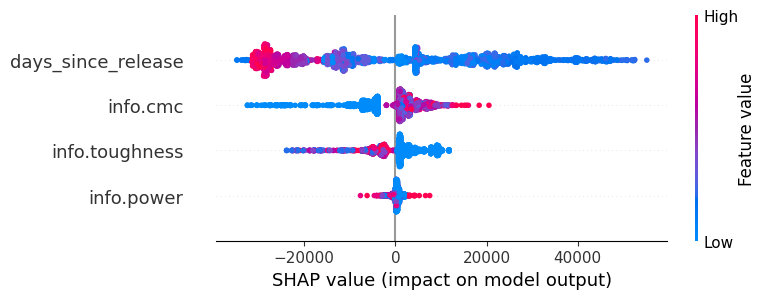

In [37]:
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(xgb.DMatrix(X_rand_test))
shap.summary_plot(shap_vals, X_rand_test, show=False)
plt.tight_layout()
plt.savefig("../report_figures/shap_summary.png")

## 10. LIME Explainability

Generate LIME explanations for a handful of samples.

FileNotFoundError: [Errno 2] No such file or directory: '../report_figures/lime_0.png'

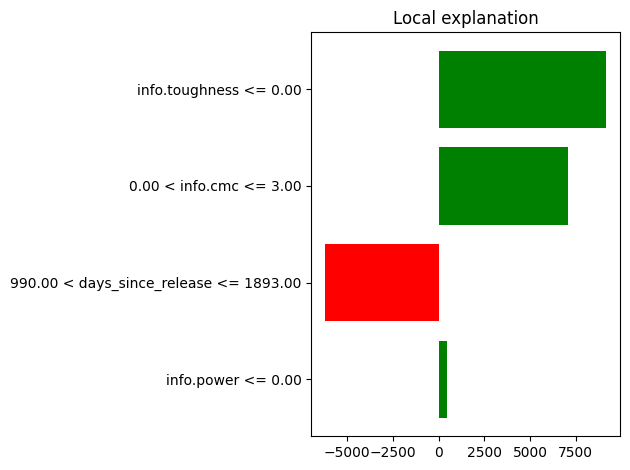

In [40]:
expl = LimeTabularExplainer(
    training_data=X_rand.values,
    feature_names=X_rand.columns.tolist(),
    mode="regression"
 )
# Wrapper for xgb_model.predict to accept numpy array and pass feature names
def xgb_predict_wrapper(x):
    return xgb_model.predict(xgb.DMatrix(x, feature_names=X_rand.columns.tolist()))
for i in [0, 5, 10]:
    exp = expl.explain_instance(
        X_rand_test.iloc[i].values, 
        xgb_predict_wrapper, 
        num_features=5
    )
    fig = exp.as_pyplot_figure()
    fig.tight_layout()
    fig.savefig(f"../report_figures/lime_{i}.png")

## 11. Recommender Evaluation

Simulate “hide‐k” experiments and compute Precision@10, nDCG@10.

In [41]:
interactions = pd.read_csv("../data/interactions.csv")
cf_model = train_cf(interactions)
content_model = train_content(X)
preds = blend_recommendations(cf_model, content_model, user_id=1, deck_pool=list(df["name"]), alpha=0.5)
metrics = evaluate_recs(true_items=[...], pred_items=preds, k=10)
print(metrics)

FileNotFoundError: [Errno 2] No such file or directory: '../data/interactions.csv'

## 12. Save Trained Models

Persist models for deployment.

In [19]:
# Cell 12: Saving
joblib.dump(rf_model, "../models/rf_model.pkl")
joblib.dump(cb_model, "../models/cb_model.pkl")
xgb_model.save_model("../models/xgb_model.json")

NameError: name 'rf_model' is not defined